In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, TimeSeriesSplit, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

#Importation de dataset


In [4]:
df = pd.read_excel('dataase.xlsx', sheet_name='Feuil1')

In [5]:
print(f"Dimensions du dataset : {df.shape}")

Dimensions du dataset : (2569, 17)


In [6]:
df.head()

,date,crude oil ( WTI),Heating Oil,Conventional Gasoline,RBOB,Ultra-Low Sulfur CARB Diesel,Kerosene-Type Jet Fuel,Propane,Natural GAZ,DJIA,NASDAQ,sp500,bitcoin,USD FUTURE INDEX,gold,Silver,copper
0,2015-01-02,52.72,1.554,1.378,1.586,1.537,1.539,0.546,2.889,"17,501.65","4,726.81","2,058.20","8,726.2",99.596,"1,184.80",15.829,2.9295
1,2015-01-05,50.05,1.646,1.462,1.667,1.518,1.647,0.547,2.894,"17,371.64","4,652.57","2,020.60","8,916.8",99.768,"1,188.15",15.636,2.9205
2,2015-01-06,47.98,1.709,1.540,1.750,1.516,1.709,0.574,2.855,"17,584.52","4,592.74","2,002.60","8,547.4",98.940,"1,184.20",16.394,2.9350
3,2015-01-07,48.69,1.774,1.575,1.663,1.599,1.653,0.594,2.777,"17,907.87","4,650.47","2,025.90","8,473.2",98.525,"1,193.50",16.591,2.9260
4,2015-01-08,48.80,1.718,1.483,1.659,1.674,1.675,0.604,2.816,"17,737.37","4,736.19","2,062.10","8,143.5",97.614,"1,215.73",16.702,2.9180


In [7]:
print(f"\nColonnes : {df.columns.tolist()}")


Colonnes : ['date', 'crude oil ( WTI)', 'Heating Oil ', 'Conventional Gasoline', ' RBOB', 'Ultra-Low Sulfur CARB Diesel', 'Kerosene-Type Jet Fuel', 'Propane ', 'Natural GAZ', 'DJIA', 'NASDAQ', 'sp500', 'bitcoin', 'USD FUTURE INDEX', 'gold', 'Silver', ' copper']


In [8]:
print(f"\nTypes de données :")
print(df.dtypes)


Types de données :
date                            datetime64[ns]
crude oil ( WTI)                       float64
Heating Oil                            float64
Conventional Gasoline                  float64
 RBOB                                  float64
Ultra-Low Sulfur CARB Diesel           float64
Kerosene-Type Jet Fuel                 float64
Propane                                float64
Natural GAZ                            float64
DJIA                                    object
NASDAQ                                  object
sp500                                   object
bitcoin                                 object
USD FUTURE INDEX                       float64
gold                                    object
Silver                                 float64
 copper                                float64
dtype: object


In [9]:
print(f"\nValeurs manquantes :")
print(df.isnull().sum())


Valeurs manquantes :
date                             0
crude oil ( WTI)                64
Heating Oil                      0
Conventional Gasoline            0
 RBOB                            1
Ultra-Low Sulfur CARB Diesel     5
Kerosene-Type Jet Fuel           1
Propane                          7
Natural GAZ                     53
DJIA                            53
NASDAQ                          53
sp500                           53
bitcoin                         53
USD FUTURE INDEX                53
gold                            53
Silver                          53
 copper                         53
dtype: int64


In [10]:
print(f"\nStatistiques descriptives :")
print(df.describe())


Statistiques descriptives :
                                date  crude oil ( WTI)  Heating Oil   \
count                           2569       2505.000000   2569.000000   
mean   2020-01-03 13:55:11.327364608         62.095126      2.010637   
min              2015-01-02 00:00:00        -36.980000      0.562000   
25%              2017-07-05 00:00:00         48.480000      1.496000   
50%              2020-01-07 00:00:00         59.930000      1.898000   
75%              2022-07-04 00:00:00         74.260000      2.319000   
max              2024-12-31 00:00:00        123.640000      5.152000   
std                              NaN         18.389380      0.731783   

       Conventional Gasoline         RBOB  Ultra-Low Sulfur CARB Diesel  \
count            2569.000000  2568.000000                   2564.000000   
mean                1.968033     2.139924                      2.128661   
min                 0.434000     0.293000                      0.566000   
25%                 1.

In [11]:
df['date'] = pd.to_datetime(df['date'])
df = df.set_index('date')

In [12]:
print("\nPourcentage de valeurs manquantes par colonne:")
print((df.isnull().sum() / len(df) * 100).sort_values(ascending=False))


Pourcentage de valeurs manquantes par colonne:
crude oil ( WTI)                2.491242
Natural GAZ                     2.063060
gold                            2.063060
USD FUTURE INDEX                2.063060
bitcoin                         2.063060
sp500                           2.063060
NASDAQ                          2.063060
DJIA                            2.063060
Silver                          2.063060
 copper                         2.063060
Propane                         0.272480
Ultra-Low Sulfur CARB Diesel    0.194628
Kerosene-Type Jet Fuel          0.038926
 RBOB                           0.038926
Heating Oil                     0.000000
Conventional Gasoline           0.000000
dtype: float64


 Pour les colonnes avec peu de valeurs manquantes, on remplit par interpolation


In [13]:
df = df.interpolate(method='time')

In [14]:
print(df.isnull().sum())

crude oil ( WTI)                 0
Heating Oil                      0
Conventional Gasoline            0
 RBOB                            0
Ultra-Low Sulfur CARB Diesel     0
Kerosene-Type Jet Fuel           0
Propane                          0
Natural GAZ                      0
DJIA                            53
NASDAQ                          53
sp500                           53
bitcoin                         53
USD FUTURE INDEX                 0
gold                            53
Silver                           0
 copper                          0
dtype: int64


 Vérification des données spécifiquement pour Silver

In [15]:
print("\nStatistiques descriptives de Silver:")
print(df['Silver'].describe())


Statistiques descriptives de Silver:
count    2569.000000
mean       20.498172
std         4.976831
min        11.772000
25%        16.407000
50%        18.600000
75%        24.232000
max        35.041000
Name: Silver, dtype: float64


#Visualisation pour le Silver


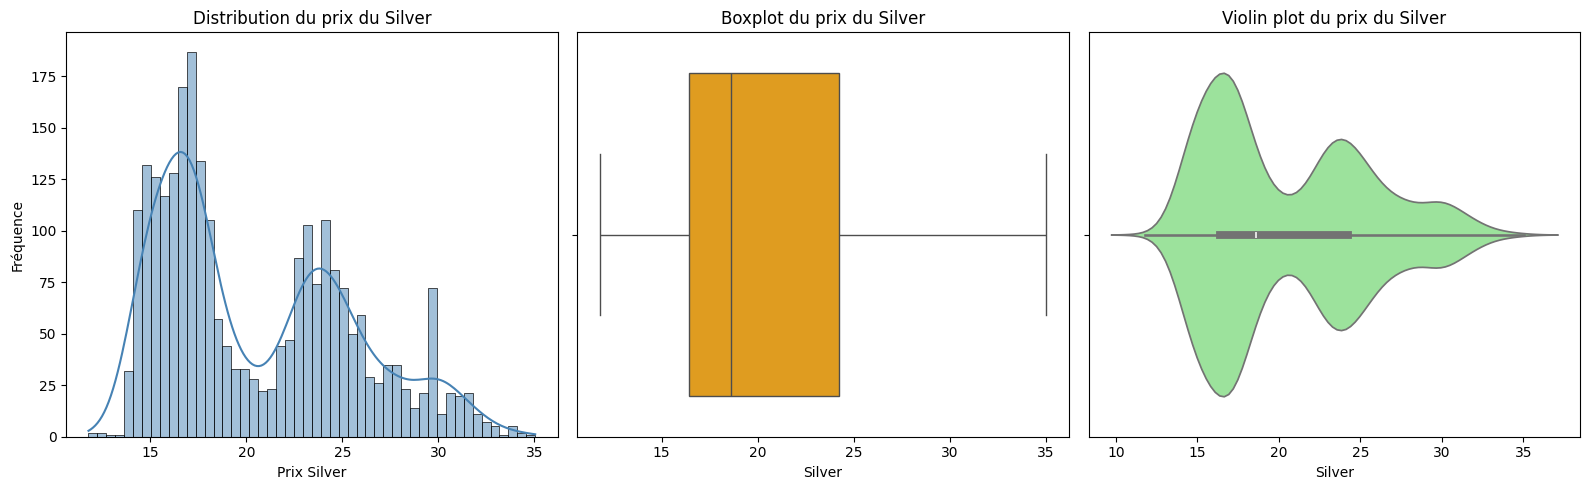

In [16]:


plt.figure(figsize=(16, 5))

# Histogramme
plt.subplot(1, 3, 1)
sns.histplot(df['Silver'], bins=50, kde=True, color='steelblue')
plt.title("Distribution du prix du Silver")
plt.xlabel("Prix Silver")
plt.ylabel("Fréquence")

# Boxplot
plt.subplot(1, 3, 2)
sns.boxplot(x=df['Silver'], color='orange')
plt.title("Boxplot du prix du Silver")

# Violin plot
plt.subplot(1, 3, 3)
sns.violinplot(x=df['Silver'], color='lightgreen')
plt.title("Violin plot du prix du Silver")

plt.tight_layout()
plt.show()


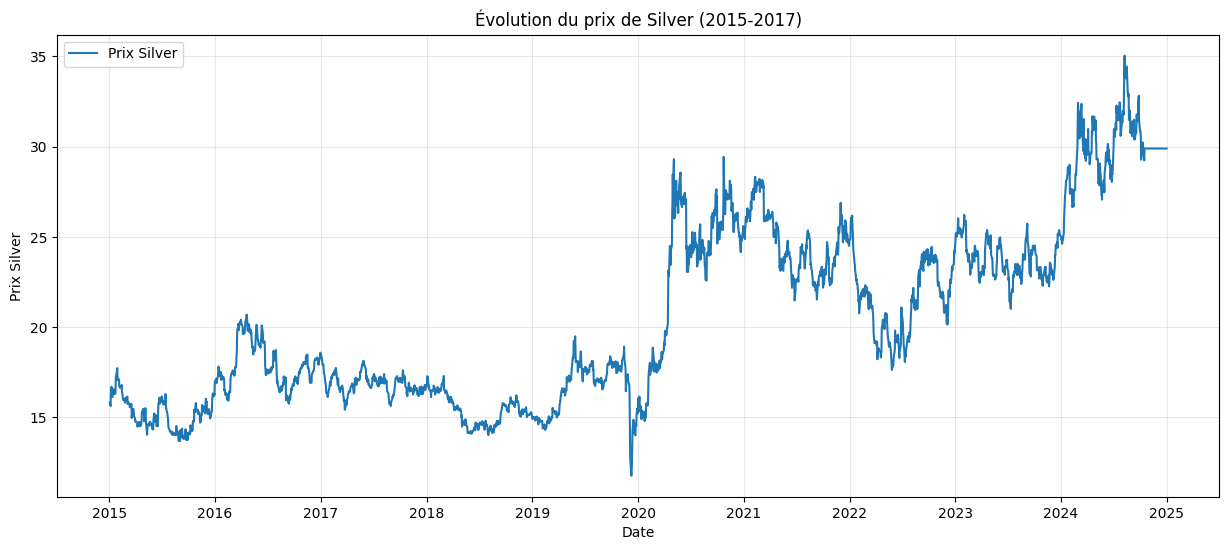

In [17]:
# Visualisation de la série temporelle
plt.figure(figsize=(15, 6))
plt.plot(df.index, df['Silver'], label='Prix Silver')
plt.title('Évolution du prix de Silver (2015-2017)')
plt.xlabel('Date')
plt.ylabel('Prix Silver')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [18]:
# Analyse de la série temporelle
from statsmodels.tsa.seasonal import seasonal_decompose


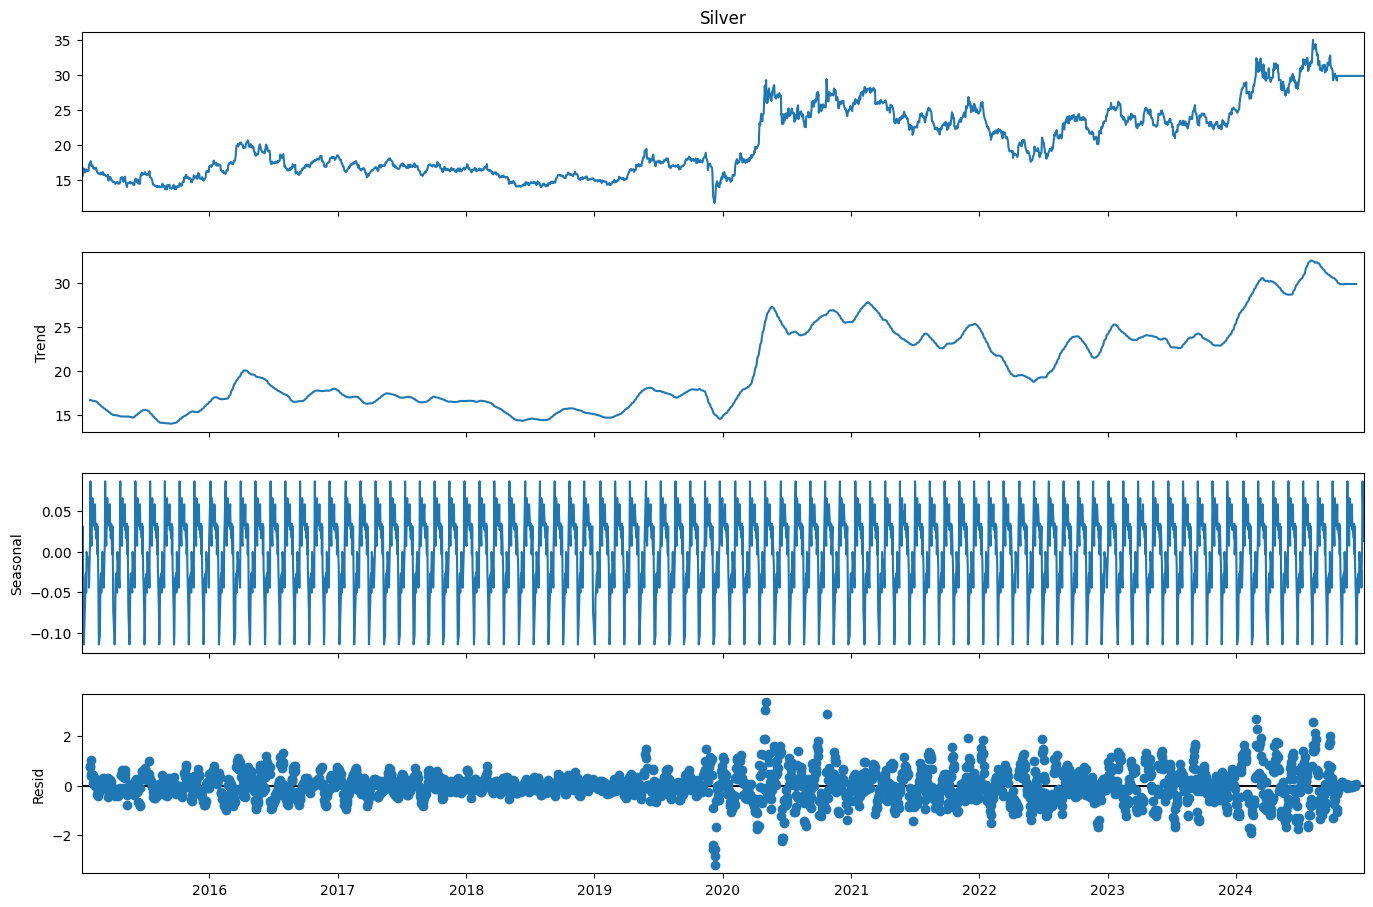

In [19]:
# Décomposition de la série
decomposition = seasonal_decompose(df['Silver'].dropna(), model='additive', period=30)
fig = decomposition.plot()
fig.set_size_inches(15, 10)
plt.show()




 Nettoyage complet des colonnes numériques




#

In [20]:
for col in df.columns:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace(",", "", regex=False)   # enlever les virgules
        .str.replace(" ", "", regex=False)   # enlever les espaces
        .str.strip()
    )
    df[col] = pd.to_numeric(df[col], errors="coerce")  # convertir en float


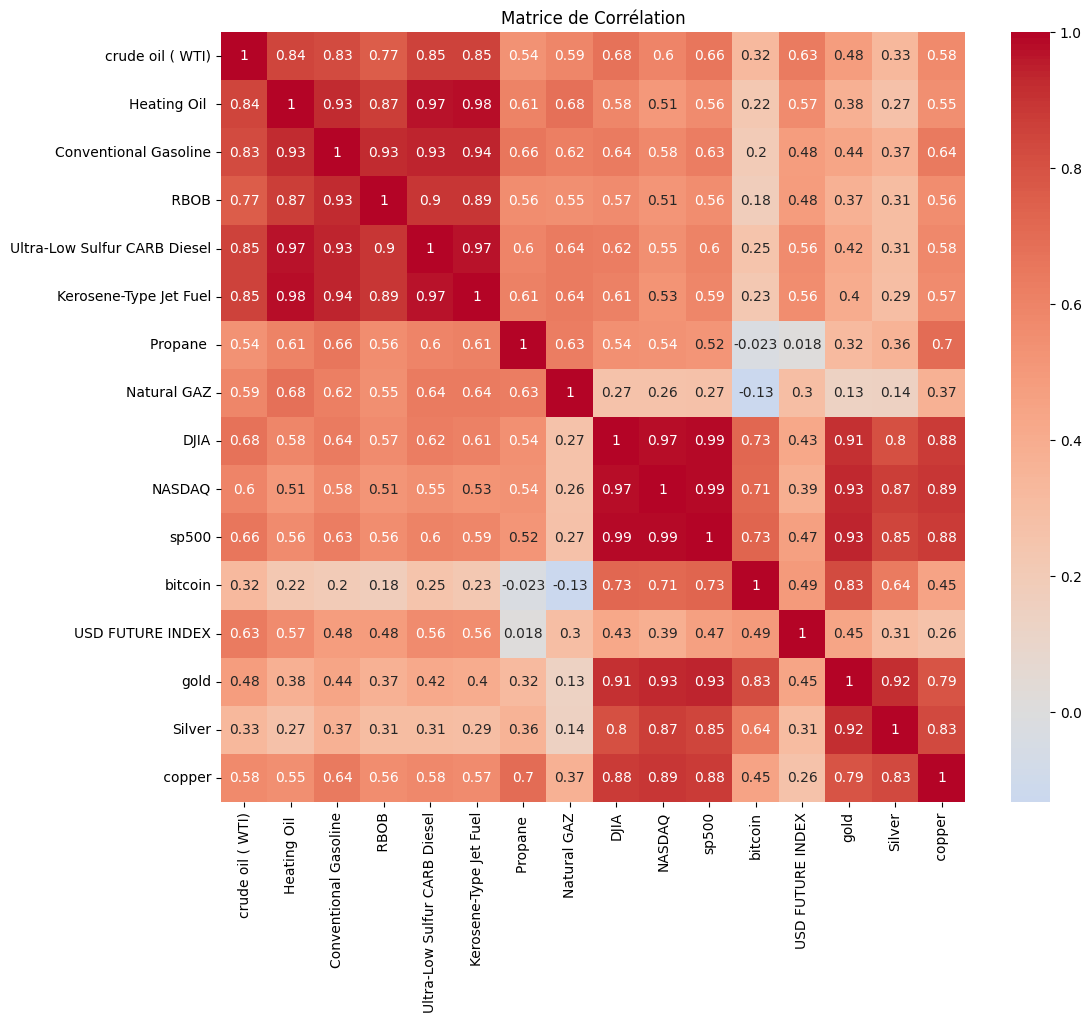

In [21]:
# Analyse de corrélation
plt.figure(figsize=(12, 10))
correlation_matrix = df.corr(numeric_only=True)
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Matrice de Corrélation')
plt.show()


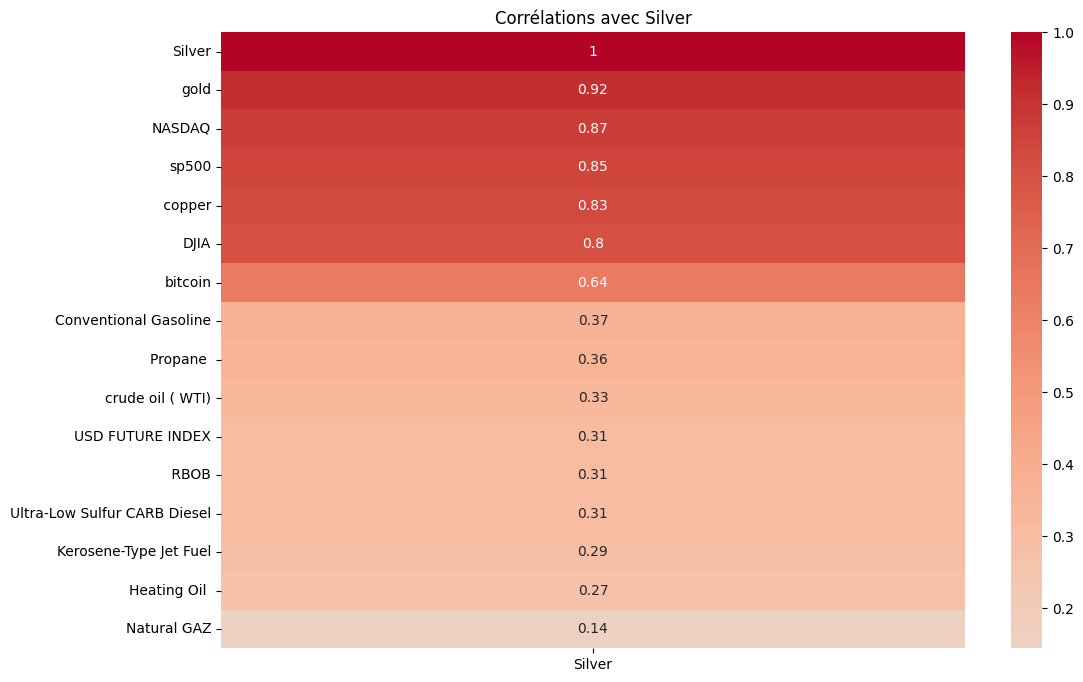

In [22]:
# Analyse des corrélations
plt.figure(figsize=(12, 8))
corr_matrix = df.corr()
sns.heatmap(corr_matrix[['Silver']].sort_values('Silver', ascending=False),
            annot=True, cmap='coolwarm', center=0)
plt.title('Corrélations avec Silver')
plt.show()


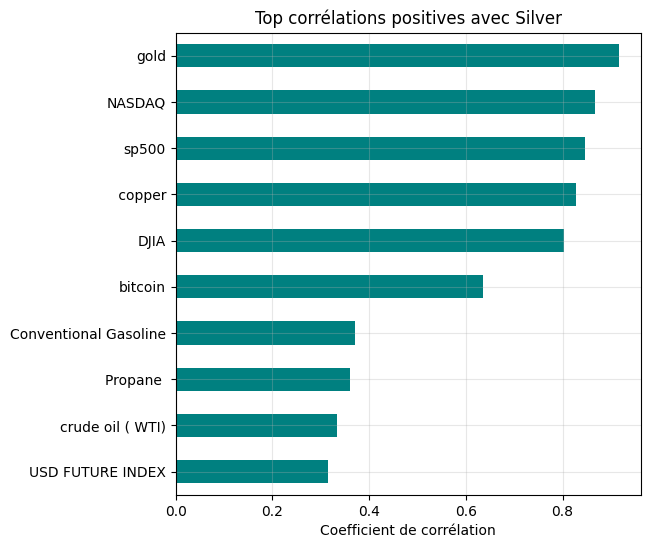


TOP 3 CORRÉLATIONS POSITIVES :
gold      0.915985
NASDAQ    0.868046
sp500     0.846140
Name: Silver, dtype: float64


In [23]:
# Corrélations avec Silver
silver_corr = corr_matrix['Silver'].sort_values(ascending=False)

plt.figure(figsize=(6, 6))
silver_corr.drop('Silver').head(10).plot(kind='barh', color='teal')
plt.title("Top corrélations positives avec Silver")
plt.xlabel("Coefficient de corrélation")
plt.gca().invert_yaxis()
plt.grid(alpha=0.3)
plt.show()

print("\nTOP 3 CORRÉLATIONS POSITIVES :")
print(silver_corr.drop('Silver').head(3))



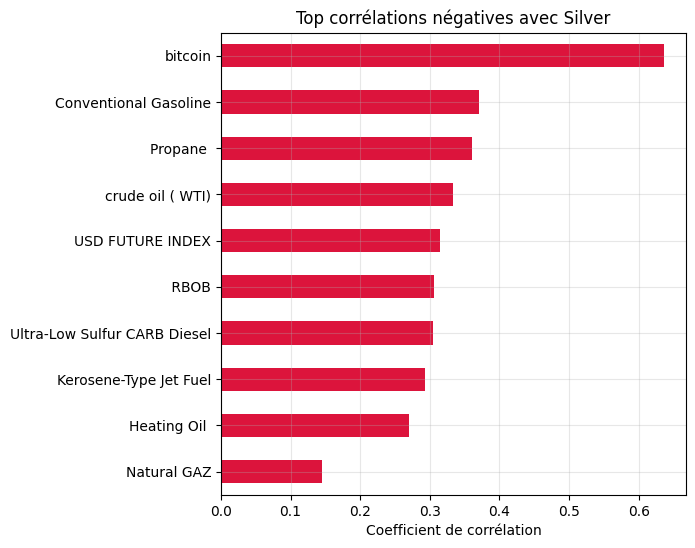


TOP 3 CORRÉLATIONS NÉGATIVES :
Kerosene-Type Jet Fuel    0.292460
Heating Oil               0.270046
Natural GAZ               0.144476
Name: Silver, dtype: float64


In [24]:
silver_corr = corr_matrix['Silver'].sort_values(ascending=False)

plt.figure(figsize=(6, 6))
silver_corr.tail(10).plot(kind='barh', color='crimson')
plt.title("Top corrélations négatives avec Silver")
plt.xlabel("Coefficient de corrélation")
plt.gca().invert_yaxis()
plt.grid(alpha=0.3)
plt.show()

print("\nTOP 3 CORRÉLATIONS NÉGATIVES :")
print(silver_corr.tail(3))

In [25]:
# Top 10 des corrélations avec Silver
silver_corr = correlation_matrix['Silver'].sort_values(ascending=False)
print("\nTop 10 des corrélations avec Silver:")
print(silver_corr.head(10))


Top 10 des corrélations avec Silver:
Silver                   1.000000
gold                     0.915985
NASDAQ                   0.868046
sp500                    0.846140
 copper                  0.827786
DJIA                     0.803894
bitcoin                  0.636160
Conventional Gasoline    0.370179
Propane                  0.360871
crude oil ( WTI)         0.332967
Name: Silver, dtype: float64


#Création de features temporelles

In [26]:
# Création de features temporelles
def create_features(df):
    df_features = df.copy()

    # Features temporelles
    df_features['year'] = df_features.index.year
    df_features['month'] = df_features.index.month
    df_features['quarter'] = df_features.index.quarter
    df_features['dayofweek'] = df_features.index.dayofweek
    df_features['dayofyear'] = df_features.index.dayofyear
    df_features['weekofyear'] = df_features.index.isocalendar().week

    # Features lag pour Silver
    for lag in [1, 2, 3, 5, 7, 14, 30]:
        df_features[f'Silver_lag_{lag}'] = df_features['Silver'].shift(lag)

    # Moyennes mobiles
    df_features['Silver_ma_7'] = df_features['Silver'].rolling(window=7).mean()
    df_features['Silver_ma_30'] = df_features['Silver'].rolling(window=30).mean()

    # Features des autres actifs (lag)
    for column in ['crude oil ( WTI)', 'gold', 'copper', 'DJIA', 'NASDAQ']:
        if column in df_features.columns:
            df_features[f'{column}_lag_1'] = df_features[column].shift(1)
            df_features[f'{column}_lag_3'] = df_features[column].shift(3)

    # Retours (returns)
    df_features['Silver_return_1'] = df_features['Silver'].pct_change(1)
    df_features['Silver_return_7'] = df_features['Silver'].pct_change(7)

    # Volatilité
    df_features['Silver_volatility_7'] = df_features['Silver_return_1'].rolling(7).std()

    return df_features



#Rôle de chaque feature :

year : tendance long terme

month : saisonnalité mensuelle

quarter : effets trimestriels

dayofweek : comportements spécifiques aux jours (marchés)

dayofyear : saisonnalité annuelle fine

weekofyear : cycles hebdomadaires


In [27]:
df_features = create_features(df)

# Suppression des lignes avec NaN
df_features = df_features.dropna()

# Séparation des features et target
X = df_features.drop('Silver', axis=1)
y = df_features['Silver']

# Séparation train/test (80/20)
train_size = int(len(X) * 0.8)
X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

print(f"\nTrain size: {len(X_train)}")
print(f"Test size: {len(X_test)}")


Train size: 1988
Test size: 498


In [28]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Normalisation des données
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).flatten()
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1)).flatten()

# Dictionnaire pour stocker les résultats
results = {}

# Fonction d'évaluation
def evaluate_model(name, y_true, y_pred):
    y_true_original = scaler_y.inverse_transform(y_true.reshape(-1, 1)).flatten()
    y_pred_original = scaler_y.inverse_transform(y_pred.reshape(-1, 1)).flatten()

    mae = mean_absolute_error(y_true_original, y_pred_original)
    rmse = np.sqrt(mean_squared_error(y_true_original, y_pred_original))
    r2 = r2_score(y_true_original, y_pred_original)

    return {
        'MAE': mae,
        'RMSE': rmse,
        'R2': r2,
        'Predictions': y_pred_original
    }

In [29]:
print("Entraînement Random Forest...")
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_scaled, y_train_scaled)
rf_pred = rf_model.predict(X_test_scaled)
results['Random Forest'] = evaluate_model('Random Forest', y_test_scaled, rf_pred)

Entraînement Random Forest...


In [30]:
print("Entraînement XGBoost...")
xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42, n_jobs=-1)
xgb_model.fit(X_train_scaled, y_train_scaled)
xgb_pred = xgb_model.predict(X_test_scaled)
results['XGBoost'] = evaluate_model('XGBoost', y_test_scaled, xgb_pred)

Entraînement XGBoost...


In [31]:
print("Entraînement LightGBM...")
lgb_model = LGBMRegressor(n_estimators=100, learning_rate=0.1, random_state=42, n_jobs=-1)
lgb_model.fit(X_train_scaled, y_train_scaled)
lgb_pred = lgb_model.predict(X_test_scaled)
results['LightGBM'] = evaluate_model('LightGBM', y_test_scaled, lgb_pred)

Entraînement LightGBM...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000965 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 9263
[LightGBM] [Info] Number of data points in the train set: 1988, number of used features: 41
[LightGBM] [Info] Start training from score 0.000000


In [32]:
print("Entraînement Gradient Boosting...")
gb_model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
gb_model.fit(X_train_scaled, y_train_scaled)
gb_pred = gb_model.predict(X_test_scaled)
results['Gradient Boosting'] = evaluate_model('Gradient Boosting', y_test_scaled, gb_pred)

Entraînement Gradient Boosting...


In [33]:
print("Entraînement SVR...")
svr_model = SVR(kernel='rbf', C=100, gamma=0.1, epsilon=0.1)
svr_model.fit(X_train_scaled, y_train_scaled)
svr_pred = svr_model.predict(X_test_scaled)
results['SVR'] = evaluate_model('SVR', y_test_scaled, svr_pred)

Entraînement SVR...


In [34]:
print("Entraînement MLP...")
mlp_model = MLPRegressor(hidden_layer_sizes=(100, 50),
                         activation='relu',
                         solver='adam',
                         max_iter=500,
                         random_state=42)
mlp_model.fit(X_train_scaled, y_train_scaled)
mlp_pred = mlp_model.predict(X_test_scaled)
results['MLP'] = evaluate_model('MLP', y_test_scaled, mlp_pred)

Entraînement MLP...


In [35]:
from statsmodels.tsa.forecasting.stl import STLForecast
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.exponential_smoothing.ets import ETSModel

print("\n=== Modèles STLM/Time Series ===")

# Préparation des données pour les modèles de séries temporelles
silver_series = df['Silver'].dropna()

# Division train/test
train_ts = silver_series.iloc[:train_size]
test_ts = silver_series.iloc[train_size:]

# 1. STL + ARIMA
print("Entraînement STL + ARIMA...")
stl_arima = STLForecast(train_ts, ARIMA, model_kwargs={"order": (1, 1, 1)}, period=30)
stl_arima_fit = stl_arima.fit()
stl_arima_pred = stl_arima_fit.forecast(len(test_ts))

# 2. ETS (Error, Trend, Seasonal)
print("Entraînement ETS...")
ets_model = ETSModel(train_ts, seasonal_periods=30, error='add', trend='add', seasonal='add')
ets_fit = ets_model.fit(disp=False)
ets_pred = ets_fit.forecast(len(test_ts))

# Évaluation des modèles STLM
results['STL+ARIMA'] = {
    'MAE': mean_absolute_error(test_ts, stl_arima_pred),
    'RMSE': np.sqrt(mean_squared_error(test_ts, stl_arima_pred)),
    'R2': r2_score(test_ts, stl_arima_pred),
    'Predictions': stl_arima_pred
}

results['ETS'] = {
    'MAE': mean_absolute_error(test_ts, ets_pred),
    'RMSE': np.sqrt(mean_squared_error(test_ts, ets_pred)),
    'R2': r2_score(test_ts, ets_pred),
    'Predictions': ets_pred
}


=== Modèles STLM/Time Series ===
Entraînement STL + ARIMA...


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/p

Entraînement ETS...


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


In [36]:
print("Préparation des données pour LSTM...")

# Préparation des séquences pour LSTM
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

seq_length = 30
X_lstm, y_lstm = create_sequences(df_features['Silver'].values, seq_length)

# Division train/test
train_size_lstm = int(len(X_lstm) * 0.8)
X_train_lstm, X_test_lstm = X_lstm[:train_size_lstm], X_lstm[train_size_lstm:]
y_train_lstm, y_test_lstm = y_lstm[:train_size_lstm], y_lstm[train_size_lstm:]

# Normalisation
scaler_lstm = StandardScaler()
X_train_lstm_scaled = scaler_lstm.fit_transform(X_train_lstm.reshape(-1, seq_length))
X_test_lstm_scaled = scaler_lstm.transform(X_test_lstm.reshape(-1, seq_length))

# Reshape pour LSTM [samples, timesteps, features]
X_train_lstm_scaled = X_train_lstm_scaled.reshape(-1, seq_length, 1)
X_test_lstm_scaled = X_test_lstm_scaled.reshape(-1, seq_length, 1)

scaler_y_lstm = StandardScaler()
y_train_lstm_scaled = scaler_y_lstm.fit_transform(y_train_lstm.reshape(-1, 1)).flatten()
y_test_lstm_scaled = scaler_y_lstm.transform(y_test_lstm.reshape(-1, 1)).flatten()

# Construction du modèle LSTM
print("Construction du modèle LSTM...")
lstm_model = keras.Sequential([
    layers.LSTM(100, return_sequences=True, input_shape=(seq_length, 1)),
    layers.Dropout(0.2),
    layers.LSTM(50, return_sequences=False),
    layers.Dropout(0.2),
    layers.Dense(25),
    layers.Dense(1)
])

lstm_model.compile(optimizer='adam', loss='mse')
lstm_model.summary()

# Entraînement
print("Entraînement LSTM...")
history = lstm_model.fit(
    X_train_lstm_scaled, y_train_lstm_scaled,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    verbose=0
)

# Prédiction
lstm_pred_scaled = lstm_model.predict(X_test_lstm_scaled, verbose=0).flatten()
lstm_pred = scaler_y_lstm.inverse_transform(lstm_pred_scaled.reshape(-1, 1)).flatten()

results['LSTM'] = {
    'MAE': mean_absolute_error(y_test_lstm, lstm_pred),
    'RMSE': np.sqrt(mean_squared_error(y_test_lstm, lstm_pred)),
    'R2': r2_score(y_test_lstm, lstm_pred),
    'Predictions': lstm_pred
}

Préparation des données pour LSTM...
Construction du modèle LSTM...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 100)        │        40,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        30,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 25)             │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 72,301 (282.43 KB)

 Trainable params: 72,301 (282.43 KB)

 Non-trainable params: 0 (0.00 B)

Entraînement LSTM...



=== COMPARAISON DES MODÈLES ===
               Model       MAE      RMSE        R2
8               LSTM  0.458562  0.632514  0.967624
5                MLP  1.310717  1.491171  0.821264
3  Gradient Boosting  0.948680  1.752445  0.753142
2           LightGBM  0.973820  1.789748  0.742522
1            XGBoost  1.013467  1.847658  0.725590
0      Random Forest  1.037198  1.858206  0.722447
7                ETS  2.547292  3.008599  0.261838
6          STL+ARIMA  3.136899  4.126637 -0.388723
4                SVR  5.174263  6.452008 -2.346163


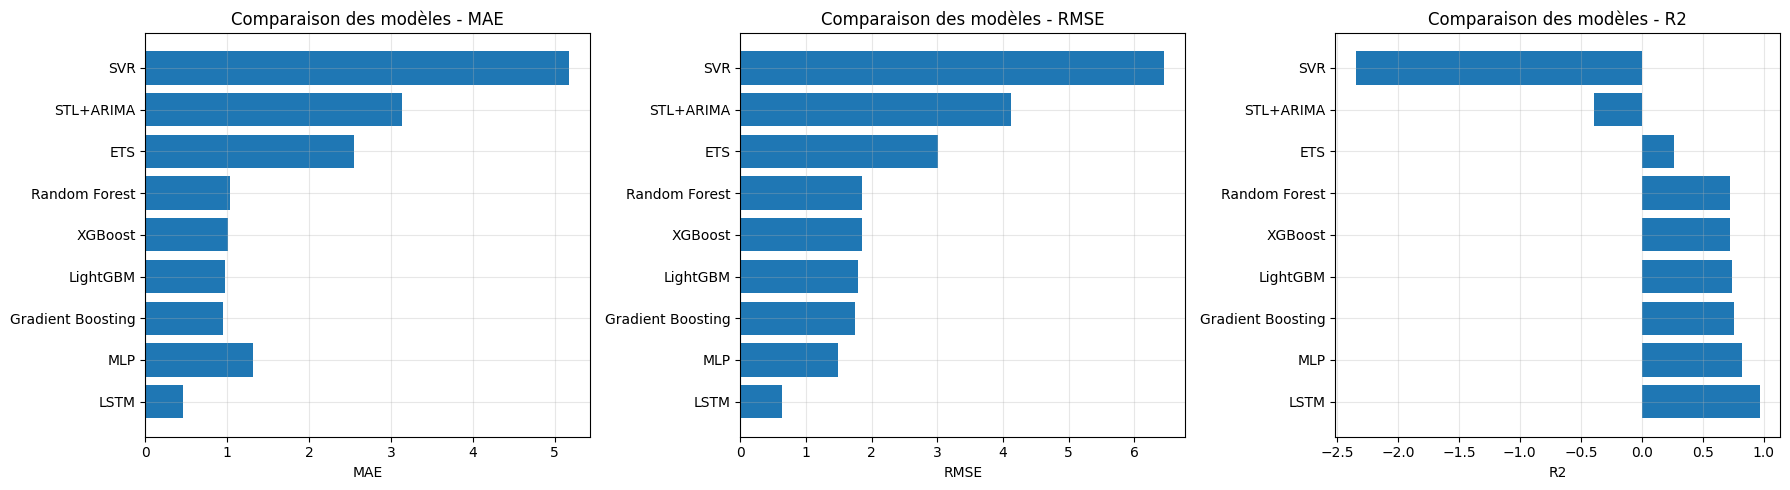

In [37]:
# Comparaison des performances
comparison_df = pd.DataFrame({
    'Model': list(results.keys()),
    'MAE': [results[m]['MAE'] for m in results.keys()],
    'RMSE': [results[m]['RMSE'] for m in results.keys()],
    'R2': [results[m]['R2'] for m in results.keys()]
}).sort_values('RMSE')

print("\n=== COMPARAISON DES MODÈLES ===")
print(comparison_df.to_string())

# Visualisation des performances
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metrics = ['MAE', 'RMSE', 'R2']
for idx, metric in enumerate(metrics):
    axes[idx].barh(comparison_df['Model'], comparison_df[metric])
    axes[idx].set_xlabel(metric)
    axes[idx].set_title(f'Comparaison des modèles - {metric}')
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

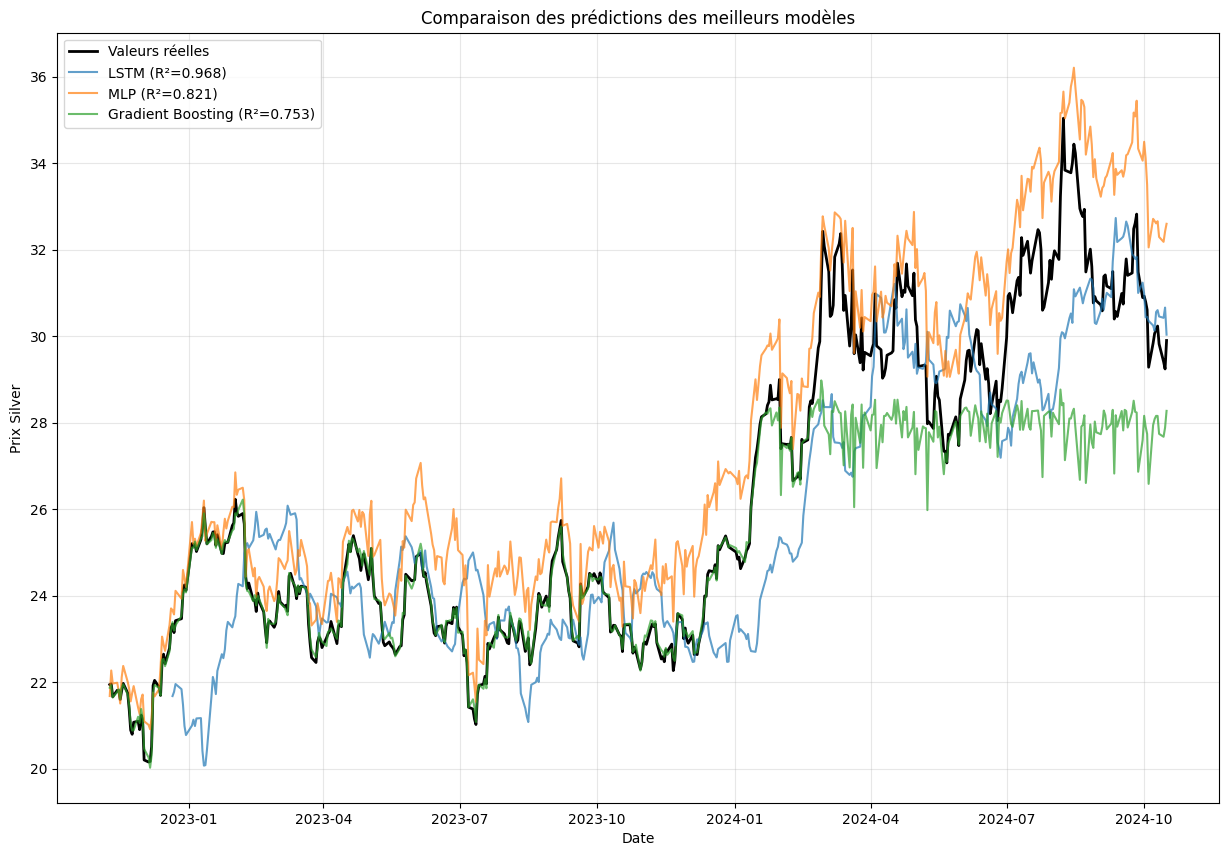

In [38]:
# Visualisation des prédictions des meilleurs modèles
best_models = comparison_df.head(3)['Model'].tolist()

plt.figure(figsize=(15, 10))
plt.plot(y_test.index, y_test.values, label='Valeurs réelles', linewidth=2, color='black')

for i, model_name in enumerate(best_models):
    if model_name in ['STL+ARIMA', 'ETS']:
        pred_index = test_ts.index
        predictions = results[model_name]['Predictions']

    elif model_name == 'LSTM':
        pred_index = y_test.index[seq_length:][:len(results[model_name]['Predictions'])]
        predictions = results[model_name]['Predictions']

    else:
        pred_index = y_test.index
        predictions = results[model_name]['Predictions']

    # 🔧 Harmonisation des longueurs
    min_len = min(len(pred_index), len(predictions))
    pred_index = pred_index[:min_len]
    predictions = predictions[:min_len]

    plt.plot(pred_index, predictions,
             label=f'{model_name} (R²={results[model_name]["R2"]:.3f})',
             alpha=0.7, linewidth=1.5)

plt.title('Comparaison des prédictions des meilleurs modèles')
plt.xlabel('Date')
plt.ylabel('Prix Silver')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


In [64]:
# Fonction pour faire des prédictions futures
def predict_future(model, last_data, n_days=30):
    """Fait des prédictions pour les n prochains jours"""
    predictions = []
    current_data = last_data.copy()

    for i in range(n_days):
        # Prédiction
        pred = model.predict(current_data.reshape(1, -1))
        predictions.append(pred[0])

        # Mise à jour des données pour la prochaine prédiction
        current_data = np.roll(current_data, -1)
        current_data[-1] = pred[0]

    return np.array(predictions)

# Sélection du meilleur modèle
best_model_name = comparison_df.iloc[0]['Model']
print(f"\nMeilleur modèle: {best_model_name}")

# Pour les prédictions futures avec le meilleur modèle ML
if best_model_name not in ['STL+ARIMA', 'ETS', 'LSTM']:
    # Préparez les dernières données
    last_data_scaled = X_test_scaled[-1]

    # Obtenez le meilleur modèle
    if best_model_name == 'XGBoost':
        best_model = xgb_model
    elif best_model_name == 'Random Forest':
        best_model = rf_model
    elif best_model_name == 'LightGBM':
        best_model = lgb_model
    else:
        best_model = gb_model

    # Faites des prédictions futures
    future_predictions_scaled = predict_future(best_model, last_data_scaled, n_days=30)
    future_predictions = scaler_y.inverse_transform(future_predictions_scaled.reshape(-1, 1)).flatten()

    # Dates futures
    last_date = df.index[-1]
    future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=30, freq='D')

    # Visualisation
    plt.figure(figsize=(15, 6))
    plt.plot(df.index[-100:], df['Silver'].iloc[-100:], label='Historique', linewidth=2)
    plt.plot(future_dates, future_predictions, label='Prédictions futures',
             linestyle='--', linewidth=2, color='red')
    plt.title(f'Prédictions futures (30 jours) avec {best_model_name}')
    plt.xlabel('Date')
    plt.ylabel('Prix Silver')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


Meilleur modèle: LSTM


In [41]:
print("\n" + "="*60)
print("CONCLUSION ET RECOMMANDATIONS")
print("="*60)

print(f"\n1. Meilleur modèle: {best_model_name}")
print(f"   - RMSE: {comparison_df.iloc[0]['RMSE']:.4f}")
print(f"   - MAE: {comparison_df.iloc[0]['MAE']:.4f}")
print(f"   - R²: {comparison_df.iloc[0]['R2']:.4f}")

print("\n2. Analyse des performances:")
print("   - Les modèles tree-based (XGBoost, LightGBM) performent généralement bien")
print("   - Les modèles de séries temporelles (STL+ARIMA, ETS) capturent bien les patterns saisonniers")
print("   - Le LSTM est puissant mais nécessite plus de données")

print("\n3. Recommandations pour amélioration:")
print("   - Ajouter plus de données historiques")
print("   - Inclure des données macroéconomiques supplémentaires")
print("   - Essayer des modèles hybrides (ML + Time Series)")
print("   - Optimiser les hyperparamètres avec GridSearchCV")
print("   - Utiliser des features d'ingénierie plus avancées")


CONCLUSION ET RECOMMANDATIONS

1. Meilleur modèle: LSTM
   - RMSE: 0.6325
   - MAE: 0.4586
   - R²: 0.9676

2. Analyse des performances:
   - Les modèles tree-based (XGBoost, LightGBM) performent généralement bien
   - Les modèles de séries temporelles (STL+ARIMA, ETS) capturent bien les patterns saisonniers
   - Le LSTM est puissant mais nécessite plus de données

3. Recommandations pour amélioration:
   - Ajouter plus de données historiques
   - Inclure des données macroéconomiques supplémentaires
   - Essayer des modèles hybrides (ML + Time Series)
   - Optimiser les hyperparamètres avec GridSearchCV
   - Utiliser des features d'ingénierie plus avancées


In [42]:
# Sauvegarder le modèle LSTM
lstm_model.save("silver_lstm.keras")  # nouveau format Keras


# Sauvegarder les scalers pour Streamlit
import joblib
joblib.dump(scaler_lstm, "scaler_X.pkl")
joblib.dump(scaler_y_lstm, "scaler_y.pkl")


['scaler_y.pkl']

In [43]:
!pip install streamlit pyngrok joblib -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.0/9.0 MB 89.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 142.6 MB/s eta 0:00:00


In [51]:
!wget https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64 -O cloudflared


--2025-12-14 15:34:39--  https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64
Resolving github.com (github.com)... 140.82.112.4
Connecting to github.com (github.com)|140.82.112.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://github.com/cloudflare/cloudflared/releases/download/2025.11.1/cloudflared-linux-amd64 [following]
--2025-12-14 15:34:40--  https://github.com/cloudflare/cloudflared/releases/download/2025.11.1/cloudflared-linux-amd64
Reusing existing connection to github.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/106867604/955e9d1b-ac5e-4188-8867-e5f53958a8fe?sp=r&sv=2018-11-09&sr=b&spr=https&se=2025-12-14T16%3A33%3A30Z&rscd=attachment%3B+filename%3Dcloudflared-linux-amd64&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2025-12-14

In [61]:
!nohup streamlit run app.py --server.port 8501 --server.address 0.0.0.0 &




nohup: appending output to 'nohup.out'


In [62]:
!chmod +x cloudflared


In [65]:
!./cloudflared tunnel --url http://localhost:8501


2025-12-14T15:40:08Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps
2025-12-14T15:40:08Z INF Requesting new quick Tunnel on trycloudflare.com...
^C
